# Encoder-Decoder Model

In this notebook, I build a simple encoder-decoder network that translates between english and german using the language data set from http://www.manythings.org/anki/. This project was part of my tensorflow specialization on coursera, which is why the model is unneccesarily complicated, using model and layer subclassing as well as custom training loops. It would be easier to use tensorflow's functional API to build the model.


In [1]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Layer
import tensorflow_hub as hub
import unicodedata
import re
import numpy as np
import json
import matplotlib.pyplot as plt

In [2]:
# GLOBAL VARIABLES


# number of examples considered from training data

NUM_EXAMPLES = 200000

# Define a global variable which bounds the maximum number of words for a
# translated sentence, roughly based on the maximal number of words in a german
# sentence in the data set (depends on NUM_EXAMPLES)

MAX_GERMAN = 25

# maximum number of words in english sentence

MAX_ENGLISH = 20

BATCH_SIZE = 32

In [3]:
# loading the dataset from
from google.colab import drive
drive.mount('/content/drive')


data_examples = []
with open('/content/drive/My Drive/Projects/Translator/deu.txt', 'r', encoding='utf8') as f:
    for line in f.readlines():
        if len(data_examples) < NUM_EXAMPLES:
            data_examples.append(line)
        else:
            break


Mounted at /content/drive


#### The custom translation model
The following is a schematic of the custom translation model architecture you will develop in this project.


![Model schematic](https://drive.google.com/uc?export=view&id=1jf9DxKGqVYdt1RS4EmvvthtPXIv9LJQ1)


The custom model consists of an encoder RNN and a decoder RNN. The encoder takes words of an English sentence as input, and uses a pre-trained word embedding to embed the words into a 128-dimensional space. To indicate the end of the input sentence, a special end token (in the same 128-dimensional space) is passed in as an input. This token is a TensorFlow Variable that is learned in the training phase (unlike the pre-trained word embedding, which is frozen).

The decoder RNN takes the internal state of the encoder network as its initial state. A start token is passed in as the first input, which is embedded using a learned German word embedding. The decoder RNN then makes a prediction for the next German word, which during inference is then passed in as the following input, and this process is repeated until the special `<end>` token is emitted from the decoder.

## 1. Text preprocessing

We first preprocess the data set and tokenize the german sentence, adding a special `"<start>"` and `"<end>"` token. We also pad the end of german sentences (english sentences are padded later).


In [4]:
# These functions preprocess English and German sentences

def unicode_to_ascii(s):
    return ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')

def preprocess_sentence(sentence):
    sentence = sentence.lower().strip()
    sentence = re.sub(r"ü", 'ue', sentence)
    sentence = re.sub(r"ä", 'ae', sentence)
    sentence = re.sub(r"ö", 'oe', sentence)
    sentence = re.sub(r'ß', 'ss', sentence)

    sentence = unicode_to_ascii(sentence)
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r"[^a-z?.!,']+", " ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)

    return sentence.strip()

In [5]:
# Create seperate lists with english and processed german sentences

english_sentences=[]
german_sentences=[]
for text in data_examples:
    english_sentences.append(preprocess_sentence(text.split('\t')[0]))
    german_sentences.append("<start> "+preprocess_sentence(text.split('\t')[1])+" <end>")


In [6]:
# use tensorflow's preprocessing tools to tokenize the sentences.
# As we use a pre-trained embedding for the english vocabulary, this is only required for the german sentences

tokenizer= tf.keras.preprocessing.text.Tokenizer(filters='')
tokenizer.fit_on_texts(german_sentences)
german_tokenized = tokenizer.texts_to_sequences(german_sentences)

In [7]:
# determine the size of german vocabuary

german_vocab = len(json.loads(tokenizer.get_config()['word_counts']))
german_vocab

25938

In [ ]:
# Print out 5 random processed sentences

for n in np.random.choice(NUM_EXAMPLES, size=5, replace=False):
    print('English Sentence: ', english_sentences[n])
    print('German Sentence : ', german_sentences[n], ' Tokenized: ',german_tokenized[n])

English Sentence:  can you order it for me ?
German Sentence :  <start> koennen sie es mir bestellen ? <end>  Tokenized:  [1, 94, 12, 13, 22, 1938, 6, 2]
English Sentence:  tom is a head taller than me .
German Sentence :  <start> tom ist einen kopf groesser als ich . <end>  Tokenized:  [1, 5, 8, 43, 673, 820, 77, 4, 3, 2]
English Sentence:  show me where it hurts .
German Sentence :  <start> zeig mir , wo es dir weh tut . <end>  Tokenized:  [1, 1107, 22, 7, 78, 13, 48, 551, 205, 3, 2]
English Sentence:  we have one advantage .
German Sentence :  <start> wir haben einen vorteil . <end>  Tokenized:  [1, 17, 35, 43, 4169, 3, 2]
English Sentence:  tom had to wait for me .
German Sentence :  <start> tom musste auf mich warten . <end>  Tokenized:  [1, 5, 473, 32, 26, 210, 3, 2]


In [ ]:
# determine maximum length of german sentences
tmp=[len(tok) for tok in german_tokenized]
print('maximum of #words in a german sentence in data set: ',max(tmp))


maximum of #words in a german sentence in data set:  23


In [8]:
# batch the padded sequences into numpy array

german_pad_tokenized = np.array(tf.keras.preprocessing.sequence.pad_sequences( german_tokenized,
     maxlen=MAX_GERMAN,  padding='post'))

## 2. Prepare the data with tf.data.Dataset objects


We use a pre-trained English word embedding module from TensorFlow Hub. The URL for the module is https://tfhub.dev/google/tf2-preview/nnlm-en-dim128-with-normalization/1. This embedding takes a batch of text tokens in a 1-D tensor of strings as input. It then embeds the separate tokens into a 128-dimensional space.

**NB:** this model can also be used as a sentence embedding module. The module will process each token by removing punctuation and splitting on spaces. It then averages the word embeddings over a sentence to give a single embedding vector. However, we will use it only as a word embedding module, and will pass each word in the input sentence as a separate token.

In [17]:
# Load embedding module from Tensorflow Hub

embedding_layer = hub.KerasLayer("https://tfhub.dev/google/tf2-preview/nnlm-en-dim128/1",
                                 output_shape=[128], input_shape=[], dtype=tf.string)

In [18]:
# Test the layer

embedding_layer(tf.constant(["these", "aren't", "the", "droids", "you're", "looking", "for"])).shape

TensorShape([7, 128])

Summary of the data cleaning process.

* Create a random training and validation set split of the data (0.8 to 0.2)
* Load the training and validation sets into a tf.data.Dataset object
* Process english sentences:
  * split each English sentence at spaces.
  * embed each sequence of English words using the loaded embedding layer
  * filter out dataset examples where the English sentence is more than 20 (embedded) tokens in length.
  * pads each sequence of embeddings of english words by zero vectors before the sequence, so that each sequence is length 20.
* Batch both training and validation Datasets with a batch size of 32.


In [13]:
# Create the test and validation data sets

from sklearn.model_selection import train_test_split

train_engl, test_engl, train_ger, test_ger = train_test_split(english_sentences, german_pad_tokenized,train_size=0.8)
train_data = tf.data.Dataset.from_tensor_slices((train_engl,train_ger))
test_data = tf.data.Dataset.from_tensor_slices((test_engl,test_ger))

# # inspect the elements

# for english, german in train_data.take(1):
#   print('English sentence: ', english.element_spec)
#   print('German sentence: ', german.element_spec)


In [14]:
# define functions for data transformations and filtering

def splitting(x,y):
    return tf.strings.split(x),y

def emb(x,y):
    return embedding_layer(x),y

def filter_maxlength(x,y,maxlength=MAX_ENGLISH):
    return len(x)<=maxlength

def padding(x,y,maxlength=MAX_ENGLISH):
    length=tf.expand_dims(MAX_ENGLISH-tf.shape(x)[0], axis=0)
    # define the padding matrix for tf.pad
    pad= tf.concat([tf.expand_dims(tf.concat([length,tf.constant([0],dtype=tf.int32)],0),0),tf.zeros([1,2],dtype=tf.int32)],0)
    x=tf.pad(x,pad, "CONSTANT")
    return x, y

In [19]:
def data_cleaning(data):
    data=data.map(splitting)
    data=data.map(emb)
    data=data.filter(filter_maxlength)
    data=data.map(padding)
    return data

train_data = data_cleaning(train_data)
test_data = data_cleaning(test_data)

train_data=train_data.batch(BATCH_SIZE)
test_data = test_data.batch(BATCH_SIZE)



In [ ]:
for english_sentence, german_sentence in train_data.take(1):
    print('Shape of the english sentence in train data batch: ',english_sentence.shape)
    print('Shape of the german sentence in test data batch: ',german_sentence.shape)
    #print(german_sentence[0].numpy())

Shape of the english sentence in train data batch:  (32, 20, 128)
Shape of the german sentence in test data batch:  (32, 25)


## 3. Create the custom layer
Create a custom layer that adds a learned end token embedding to the encoder model:


In [9]:
class CustomLayer(Layer):
    def __init__(self, **kwargs):
        super(CustomLayer, self).__init__(**kwargs)
        # the custom layer adds a new endtoken to an english sentence that can be learned
        self.end_token = self.add_weight(shape=[1,1,128],initializer = 'random_normal')

    def call(self,inputs):
        tiling= tf.constant([inputs.shape[0],1,1],dtype=tf.int32)
        repeated_endtoken= tf.tile(self.end_token,tiling)
        modified_input= tf.concat([inputs,repeated_endtoken],axis=1)
        return modified_input



In [ ]:
# apply the custom layer to the english sentence input data from the training data
# print out the shape of the returned data

custom_layer = CustomLayer()
for english_sentence, german_sentence in train_data.take(1):
    print('Originial input data: ',english_sentence.shape)
    print('Modified input data: ',custom_layer(english_sentence).shape)

Originial input data:  (32, 20, 128)
Modified input data:  (32, 21, 128)


## 4. Build the encoder network
The encoder network is built according to the following schematic diagram:

![encoder](https://drive.google.com/uc?export=view&id=13lf782htqnBo4hbTngFu2hvTWHDQRcB6)


I.e. the encoder network is build as follows:

- The model takes a batch of sequences of embedded English words as input;
- The next layer is the custom layer defined above that adds a learned end token embedding to the end of the English sequence;
- Then comes a masking layer (the padding value is the zero vector);
- The final layer is an LSTM layer with 512 units, which also returns the hidden and cell states.


In [10]:
class Encoder(Model):
    def __init__(self,**kwags):
        super(Encoder,self).__init__()
        self.custom_layer = CustomLayer()
        self.masking_layer = tf.keras.layers.Masking(mask_value=tf.zeros([1,128],dtype=tf.float32))
        self.lstm_layer = tf.keras.layers.LSTM(512, return_sequences=True,return_state=True,use_cudnn=False)

    def call(self,inputs):
        x = self.custom_layer(inputs)
        x = self.masking_layer(x)
        return self.lstm_layer(x)


In [ ]:
encoder = Encoder()
for enligsh_sentence, _ in train_data.take(1):
    for element in encoder(english_sentence):
        print(element.shape)
        #print(element.numpy())




(32, 21, 512)
(32, 512)
(32, 512)


In [ ]:
encoder.summary()

Model: "encoder_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ custom_layer_19 (CustomLayer)   │ ?                      │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ masking_16 (Masking)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_21 (LSTM)                  │ ((32, 21, 512), (32,   │     1,312,768 │
│                                 │ 512), (32, 512))       │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,312,896 (5.01 MB)

 Trainable params: 1,312,896 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Build the decoder network
The decoder network follows the schematic diagram below.

![Decoder schematic](https://drive.google.com/uc?export=view&id=1yyPnFOX0kAWzKCMzX-4jyAxV-Xmdt_K-)

More precisely, the decoder is built as follows:
- An Embedding layer with vocabulary size set to the number of unique German tokens, embedding dimension 128, and set to mask zero values in the input.
- An LSTM layer with 512 units, that returns its hidden and cell states, and also returns sequences.
- A Dense layer with number of units equal to the number of unique German tokens, and no activation function.
    
The call method includes the additional keyword arguments `hidden_state` and `cell_state` which are obtained from the encoder (with None as default).


In [11]:
class Decoder(Model):
    def __init__(self,**kwags):
        super(Decoder,self).__init__()
        self.embedding  = tf.keras.layers.Embedding(german_vocab+1,128,mask_zero=True)
        self.lstm = tf.keras.layers.LSTM(512,return_sequences=True,return_state=True)
        self.dense = tf.keras.layers.Dense(german_vocab+1)

    def call(self,inputs,hidden_state=None,cell_state=None):
        x = self.embedding(inputs)
        x_output, *x_states = self.lstm(x, initial_state=[hidden_state,cell_state])
        return self.dense(x_output)

In [20]:
encoder=Encoder()
decoder=Decoder()
for english_sentence, german_sentence in train_data.take(1):
    encoder_output, *encoder_state = encoder(english_sentence)
    decoder_output = decoder(inputs=german_sentence, hidden_state=encoder_state[0],cell_state=encoder_state[1])

#  # output of the decoder
# print(decoder_output.shape)
# print(encoder_state[0].numpy())



In [ ]:
#decoder_output

In [ ]:
decoder.summary()

Model: "decoder_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (32, 25, 128)          │     3,320,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_23 (LSTM)                  │ ((32, 25, 512), (32,   │     1,312,768 │
│                                 │ 512), (32, 512))       │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (32, 25, 25939)        │    13,306,707 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,939,667 (68.43 MB)

 Trainable params: 17,939,667 (68.43 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Make a custom training loop

In this part we run a custom training loop to train the neural translation model. It is implemented as follows:

* Define a function that takes a Tensor batch of German data (as extracted from the training Dataset), and returns a tuple containing German inputs and outputs for the decoder model (refer to schematic diagram above).
* Define a function that computes the forward and backward pass for your translation model:
    * First, we pass the English input into the encoder to get the hidden and cell states of the encoder LSTM.
    * These are then passed into the decoder, along with the German inputs, which returns a sequence of outputs.
    * The loss should then be computed between the decoder outputs and the German output function argument via categorical cross entropy.
    * return the loss and gradients with respect to the encoder and decoder’s trainable variables.


In [ ]:
categorical_loss = tf.keras.losses.CategoricalCrossentropy(from_logits=True)
#categorical_loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

In [ ]:
# given a german sentence, this function return the same sentence without the last word token
# as well as the same sentence without the fist word token as a one-hot encoded vector

def input_output(sentence):
    return sentence[:,0:MAX_GERMAN-1], tf.keras.utils.to_categorical(sentence[:,1:MAX_GERMAN],num_classes=german_vocab+1)
    #return sentence[:,0:MAX_GERMAN-1],sentence[:,1:MAX_GERMAN]



In [23]:
# # Test cell to check the encoder and decoder outputs

# for english_sentence, german_sentence in train_data.take(1):
#     german_input, german_output = input_output(german_sentence)
#     encoder_output, *encoder_state = encoder(english_sentence)
#     decoder_output = decoder(inputs=german_input, hidden_state=encoder_state[0],cell_state=encoder_state[1])

# print('encoder output: ',encoder_state[0].numpy())
# print('decoder output: ',decoder_output.numpy())



In [ ]:
# Define the gradient function for a custom training loop

@tf.function
def grad(encoder,decoder,english_input,german_input,german_output):
    with tf.GradientTape() as tape:
        #tape.watch(encoder.trainable_variables + decoder.trainable_variables)
        encoder_output, *encoder_state = encoder(english_input)
        decoder_output = decoder(inputs=german_input, hidden_state=encoder_state[0],cell_state=encoder_state[1])
        loss =  tf.reduce_sum(categorical_loss(german_output,decoder_output))
    gradient = tape.gradient(loss, encoder.trainable_variables + decoder.trainable_variables)
    return loss, gradient

In [21]:
# load the most recent model

encoder.load_weights('/content/drive/My Drive/Projects/Translator/encoder200000-25-20-date-6-3-25.weights.h5')
decoder.load_weights('/content/drive/My Drive/Projects/Translator/decoder200000-25-20-date-6-3-25.weights.h5')



In [ ]:
# load the training history

train_loss_results = [3.014,1.777, 1.422,0.996, 0.751,0.601]
validation_loss_results = [2.203,1.641,1.362, 1.272,1.178,1.237]

# I have not written the training history to file when training on colab. So instead, I have manually recorded it here. Obviously I haven't trained for many epochs.


In [ ]:
## CUSTOM TRAINING LOOP


num_epochs = 15
#weight_decay = 0.004

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

for epoch in range(num_epochs):
    epoch_loss_avg = tf.keras.metrics.Mean()
    validation_loss_avg = tf.keras.metrics.Mean()


    for english_sentence, german_sentence in train_data:
        # Optimize the model
        german_input , german_output = input_output(german_sentence)
        batch_loss, grads = grad(encoder,decoder, english_sentence , german_input
                                 ,german_output)

        optimizer.apply_gradients(zip(grads, encoder.trainable_variables+decoder.trainable_variables))

        # record the average loss on a batch per epoch
        epoch_loss_avg(batch_loss)

    #save the model
    #SET THE CURRENT DATE TO PREVENT TRAINING LOSS
    encoder.save_weights('/content/drive/My Drive/Projects/Translator/encoder200000-25-20-date-6-3-25.weights.h5')
    decoder.save_weights('/content/drive/My Drive/Projects/Translator/decoder200000-25-20-date-6-3-25.weights.h5')


    for english_sentence, german_sentence in test_data.shuffle(100).take(50):
        # Optimize the model
        german_input , german_output = input_output(german_sentence)
        encoder_output, *encoder_state = encoder(english_sentence)
        decoder_output = decoder(inputs=german_input, hidden_state=encoder_state[0],cell_state=encoder_state[1])

        #record the average loss on 50 batches of the validation set
        validation_batch_loss =  tf.reduce_sum(categorical_loss(german_output,decoder_output))
        validation_loss_avg(validation_batch_loss)

    train_loss_results.append(epoch_loss_avg.result())
    validation_loss_results.append(validation_loss_avg.result())

    print("Epoch {:03d} -- Loss: {:.3f} -- Validation Loss: {:.3f}".format(epoch,epoch_loss_avg.result(),validation_loss_avg.result()))

Epoch 000 -- Loss: 1.422 -- Validation Loss: 1.362
Epoch 001 -- Loss: 0.996 -- Validation Loss: 1.272
Epoch 002 -- Loss: 0.751 -- Validation Loss: 1.178
Epoch 003 -- Loss: 0.601 -- Validation Loss: 1.237


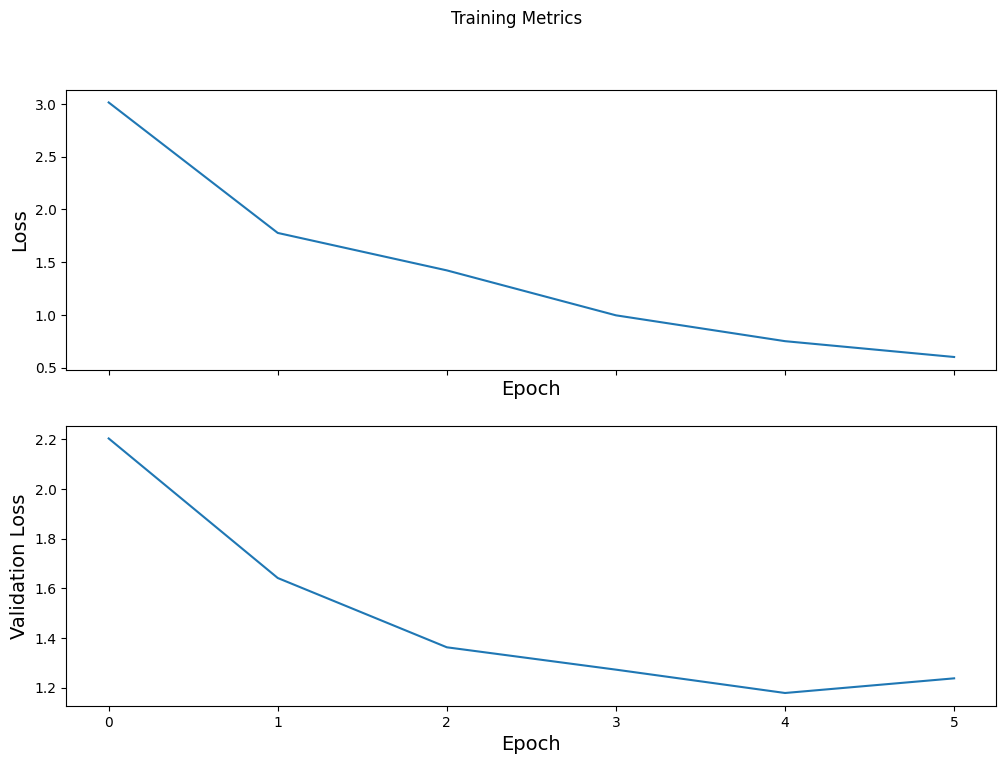

In [ ]:
fig, axes = plt.subplots(2, sharex=True, figsize=(12, 8))
fig.suptitle('Training Metrics')

axes[0].set_ylabel("Loss", fontsize=14)
axes[0].set_xlabel("Epoch", fontsize=14)
axes[0].plot(train_loss_results)

axes[1].set_ylabel("Validation Loss", fontsize=14)
axes[1].set_xlabel("Epoch", fontsize=14)
axes[1].plot(validation_loss_results)
plt.show()

## 7. Use the model to translate
Translate ten randomly sampled English sentences from the dataset:

In [35]:
for n in np.random.choice(NUM_EXAMPLES, size=10, replace=False):
    engl_sentence = embedding_layer(tf.strings.split(english_sentences[n]))
    num_words = engl_sentence.shape[0]
    pad = tf.constant([[0,0],[0,MAX_ENGLISH-num_words],[0,0]])
    english_input=tf.pad(tf.expand_dims(engl_sentence,axis=0),pad, "CONSTANT")
    encoder_output, *encoder_state = encoder(english_input)
    german_translation = tf.constant([[1]],dtype=tf.int32)

    #put in while loop
    while german_translation.shape[1] <= MAX_GERMAN:
        #print('length',german_translation.shape[1])

        post_pad = [[0,0],[0,MAX_GERMAN-german_translation.shape[0]]]
        german_input = tf.pad(german_translation,post_pad,'CONSTANT')
        decoder_output = decoder(inputs=german_input, hidden_state=encoder_state[0],cell_state=encoder_state[1])

        next_word = decoder_output.numpy()[:,german_translation.shape[1]-1,:].argmax()
        if next_word == 2 :
            break
        else:
            german_translation = tf.concat([german_translation,tf.constant([[next_word]],dtype=tf.int32)],axis=1)

    print('english sentence: ',english_sentences[n])
    print('translation: ',tokenizer.sequences_to_texts(german_translation.numpy().tolist())[0][8:])

english sentence:  why don't you come with me ?
translation:  warum kommst du nicht mit mir ?
english sentence:  stay with us , tom .
translation:  bleib bei uns , tom !
english sentence:  he is writing a novel .
translation:  er schreibt gerade einen roman .
english sentence:  i think it's too cold to swim .
translation:  ich glaube , es ist zu kalt zum schwimmen .
english sentence:  he died without having made a will .
translation:  er starb , ohne ein testament gemacht .
english sentence:  guess who i saw today .
translation:  ratet mal , dass ich heute gesehen habe !
english sentence:  is this what tom wants ?
translation:  ist das hier , was tom will ?
english sentence:  i'll do that for you , tom .
translation:  ich werde das fuer dich tun , tom .
english sentence:  tom has tiny feet .
translation:  tom hat eine kleine fuesse .
english sentence:  i wash my car almost every day .
translation:  ich wasche meinen wagen fast taeglich .
